# Concrete Strength Prediction - Model Training V1
This notebook builds a clean prototype to predict `Max_Load_lbf` and compare candidate regression models.

## 1. Imports
Import core libraries, modeling tools, and define XGBoost availability with a fallback path.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.base import clone
import difflib

try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception:
    xgb_available = False

print(f"XGBoost available: {xgb_available}")

XGBoost available: True


## 2. Load Dataset
Load the Excel dataset from the project `data` folder.

In [2]:
data_path = "../data/Sweetcrete_Master_Final.xlsx"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

try:
    df = pd.read_excel(data_path, engine="openpyxl")
except Exception as exc:
    raise RuntimeError(
        "Unable to read ../data/Sweetcrete_Master_Final.xlsx. "
        "Confirm the file is a valid non-empty .xlsx workbook."
    ) from exc

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Inspect Data
Check shape, column names, sample rows, and missing values.

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nHead:")
display(df.head())

missing_sorted = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (descending):")
display(missing_sorted)

Shape: (179, 24)

Columns:
['Mix_ID', 'PCC_%', 'Age_days', 'Sample_No', 'Weight_lb', 'Avg_Length_in', 'Avg_Diameter_in', 'Area_in2', 'Max_Load_lbf', 'Max_Stress_psi', 'Strength_MPa', 'Water_lbs', 'Cement_lbs', 'FineAgg_lbs', 'CoarseAgg_lbs', 'PCC_lbs', 'WaterCement_Ratio', 'TotalAgg_lbs', 'FineCoarse_Ratio', 'TotalMix_lbs', 'PCC_Fraction', 'PCC_Cement_Ratio', 'Cylinder_Volume_in3', 'Density_lb_per_in3']

Head:


,Mix_ID,PCC_%,Age_days,Sample_No,Weight_lb,Avg_Length_in,Avg_Diameter_in,Area_in2,Max_Load_lbf,Max_Stress_psi,...,CoarseAgg_lbs,PCC_lbs,WaterCement_Ratio,TotalAgg_lbs,FineCoarse_Ratio,TotalMix_lbs,PCC_Fraction,PCC_Cement_Ratio,Cylinder_Volume_in3,Density_lb_per_in3
0,Normal Concrete,0,1,1,8.1470,7.985,4.007,12.610391,19497.016,1545.272,...,304.436,0.0,0.436649,455.092,0.494869,640.684,0.0,0.0,100.693975,0.080909
1,0% PCC,0,1,1,8.4490,8.140,4.006,12.610000,30120.600,2389.460,...,221.408,0.0,0.436649,330.976,0.494869,465.952,0.0,0.0,102.597358,0.082351
2,Normal Concrete,0,1,2,8.1025,8.055,3.995,12.534974,21596.262,1722.880,...,304.436,0.0,0.436649,455.092,0.494869,640.684,0.0,0.0,100.969218,0.080247
3,0% PCC,0,1,2,8.4950,8.037,3.999,12.560000,22986.600,1829.850,...,221.408,0.0,0.436649,330.976,0.494869,465.952,0.0,0.0,100.945429,0.084154
4,Normal Concrete,0,1,3,8.0880,7.977,3.983,12.459783,17411.811,1396.032,...,304.436,0.0,0.436649,455.092,0.494869,640.684,0.0,0.0,99.391693,0.081375



Missing values (descending):


Area_in2               3
Max_Load_lbf           1
Mix_ID                 0
FineAgg_lbs            0
Cylinder_Volume_in3    0
PCC_Cement_Ratio       0
PCC_Fraction           0
TotalMix_lbs           0
FineCoarse_Ratio       0
TotalAgg_lbs           0
WaterCement_Ratio      0
PCC_lbs                0
CoarseAgg_lbs          0
Cement_lbs             0
PCC_%                  0
Water_lbs              0
Strength_MPa           0
Max_Stress_psi         0
Avg_Diameter_in        0
Avg_Length_in          0
Weight_lb              0
Sample_No              0
Age_days               0
Density_lb_per_in3     0
dtype: int64

## 4. Clean Missing Data
Drop rows where the target (`Max_Load_lbf`) is missing.

In [4]:
target_col = "Max_Load_lbf"

if target_col not in df.columns:
    raise ValueError(f"Missing required target column: {target_col}")

before_rows = len(df)
df = df.dropna(subset=[target_col]).copy()
after_rows = len(df)
print(f"Dropped {before_rows - after_rows} rows with missing {target_col}.")
print(f"Remaining rows: {after_rows}")

Dropped 1 rows with missing Max_Load_lbf.
Remaining rows: 178


## 5. Feature Engineering
Create engineered features from existing numeric columns.

In [5]:
required_for_engineering = ["Age_days", "WaterCement_Ratio"]
missing_engineering = [col for col in required_for_engineering if col not in df.columns]
if missing_engineering:
    suggestions = {}
    for col in missing_engineering:
        match = difflib.get_close_matches(col, df.columns.tolist(), n=1)
        suggestions[col] = match[0] if match else "No close match found"
    raise ValueError(
        f"Missing engineering columns: {missing_engineering}. Suggestions: {suggestions}"
    )

df["Log_Age"] = np.log(df["Age_days"])
df["Age_squared"] = df["Age_days"] ** 2
df["Age_x_WC"] = df["Age_days"] * df["WaterCement_Ratio"]
print("Engineered features created: Log_Age, Age_squared, Age_x_WC")

Engineered features created: Log_Age, Age_squared, Age_x_WC


## 6. Feature Selection
Use the custom Version 1 selected feature set.

In [6]:
feature_cols = [
    "Log_Age",
    "WaterCement_Ratio",
    "PCC_Cement_Ratio",
    "Density_lb_per_in3",
    "Weight_lb"
]

missing_features = [col for col in feature_cols if col not in df.columns]
if missing_features:
    suggestions = {}
    for col in missing_features:
        match = difflib.get_close_matches(col, df.columns.tolist(), n=1)
        suggestions[col] = match[0] if match else "No close match found"
    raise ValueError(
        f"Missing selected feature columns: {missing_features}. Suggestions: {suggestions}"
    )

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Selected features:", feature_cols)
print("Target:", target_col)

Selected features: ['Log_Age', 'WaterCement_Ratio', 'PCC_Cement_Ratio', 'Density_lb_per_in3', 'Weight_lb']
Target: Max_Load_lbf


## 7. Train-Test Split
Split data into train and test sets with a fixed random state for reproducibility.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (142, 5)
Test shape: (36, 5)


## 8. Model Definitions
Define candidate pipelines for Version 1, including XGBoost fallback logic.

In [8]:
models = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "ElasticNet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000))
    ]),
    "LinearRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42))
    ])
}

if xgb_available:
    models["XGBoost"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42
        ))
    ])
else:
    models["KNeighbors"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ])

print("Models configured:", list(models.keys()))

Models configured: ['Ridge', 'ElasticNet', 'LinearRegression', 'RandomForest', 'XGBoost']


## 9. Model Training and Evaluation
Train each model, compute test metrics, and evaluate with 10-fold cross-validation.

In [9]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

for model_name, model_pipe in models.items():
    working_model = clone(model_pipe)
    working_model.fit(X_train, y_train)
    y_pred = working_model.predict(X_test)

    test_r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    cv_scores = cross_val_score(
        clone(model_pipe), X_train, y_train, cv=kf, scoring="r2"
    )

    results.append({
        "Model": model_name,
        "Test_R2": test_r2,
        "MAE": mae,
        "RMSE": rmse,
        "CV_R2_Mean": cv_scores.mean(),
        "CV_R2_STD": cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="CV_R2_Mean", ascending=False
).reset_index(drop=True)

## 10. Results Comparison
Display model performance sorted by cross-validation R2 mean.

In [10]:
display(results_df)

,Model,Test_R2,MAE,RMSE,CV_R2_Mean,CV_R2_STD
0,Ridge,0.784875,8391.265399,11657.901863,0.711165,0.275276
1,ElasticNet,0.785074,8390.101478,11652.490940,0.711121,0.275523
2,LinearRegression,0.785543,8387.234942,11639.783214,0.711006,0.275960
3,RandomForest,0.758735,7277.518179,12345.859473,-0.038675,1.546612
4,XGBoost,0.585543,8327.756770,16181.337380,-0.368387,1.920727


## 11. Visualization
Plot and save model comparison using 10-fold CV R2 mean.

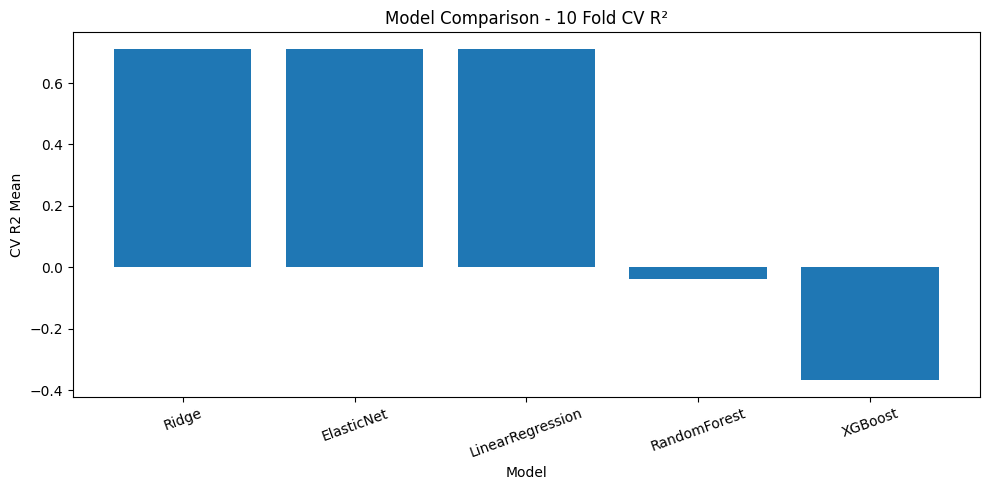

Saved chart to: ../outputs/model_comparison_v1.png


In [11]:
os.makedirs("../outputs", exist_ok=True)

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["CV_R2_Mean"])
plt.title("Model Comparison - 10 Fold CV R²")
plt.xlabel("Model")
plt.ylabel("CV R2 Mean")
plt.xticks(rotation=20)
plt.tight_layout()

plot_path = "../outputs/model_comparison_v1.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print(f"Saved chart to: {plot_path}")

## 12. Save Best Model
Refit the best model on full data and save it for reuse.

In [12]:
os.makedirs("../models", exist_ok=True)

best_model_name = results_df.loc[0, "Model"]
best_model = clone(models[best_model_name])
best_model.fit(X, y)

model_path = "../models/best_model_v1.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Best model: {best_model_name}")
print(f"Saved model to: {model_path}")

Best model: Ridge
Saved model to: ../models/best_model_v1.pkl


## 13. Conclusion
This prototype predicts `Max_Load_lbf`, uses the five custom selected features, compares five regression models, and selects the best one using 10-fold CV R2 (supported by test R2, MAE, and RMSE).

The workflow is inspired by prior SweetCrete work while using a customized feature/model setup for Version 1.